In [7]:
from typing import TypedDict
from langgraph.graph import StateGraph,START,END

In [8]:
class AgentState(TypedDict):
    num1:int
    num2:int
    operation:str
    final:str

In [ ]:
def adder(state:AgentState)->AgentState:
    """This function adds two no.s"""
    state["final"]=state["num1"]+state["num2"]
    return state


def subtractor(state:AgentState)->AgentState:
    """This function subtracts two no.s"""
    state["final"]=state["num1"]-state["num2"]
    return state


def decision_maker(state:AgentState)->AgentState:
    """This function decides which operator to use"""
    if(state["operation"]=='+'):
        return "addition_operator"
    
    else:
        return "subtraction_operator"
    

In [10]:
graph=StateGraph(AgentState)

graph.add_node("add",adder)
graph.add_node("subtract",subtractor)
graph.add_node("router",lambda state:state)

graph.add_edge(START,"router")
graph.add_conditional_edges(
    "router",
    decision_maker,
    {
        "addition_operator":"add" ,
        "subtraction_operator":"subtract"

    }
)

graph.add_edge("add",END)
graph.add_edge("subtract",END)

app=graph.compile()


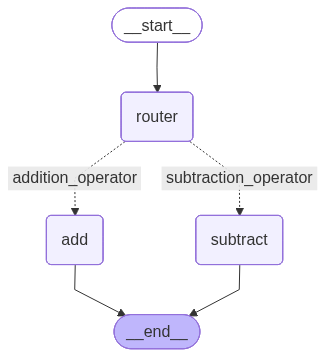

In [11]:
from IPython.display import Image,display

display(Image(app.get_graph().draw_mermaid_png()))

In [12]:
sample_input=AgentState({"num1":29,"num2":8,"operation":"+","final":""})
print(app.invoke(sample_input))

{'num1': 29, 'num2': 8, 'operation': '+', 'final': 37}
